## Analyse du Churn Bancaire
## 01 - ETL (Extract, Transform, Load)
### Objectif : Néttoyer et préparer le Dataset 

#### 01.1- Importation des librairies 

In [110]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib as plt
import sklearn  as skl 

#### 01.2- Chargement du dataset et Affichage de 5 premières lignes

In [111]:
df = pd.read_csv("../Data/Data_brut/Customer-Churn-Records.csv")
print("=> Shape:", df.shape)
df.head()

=> Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


#### 01.3- Interrogation du Dataset pour voir sa composition

In [112]:
inf = df.info()
print(inf)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

#### 01.4- Vérification de l'existance des varleurs manquantes dans dataset

In [113]:
print("=> les valeurs manquantes par variable")
df.isnull().sum()


=> les valeurs manquantes par variable


RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

#### 01.5- Vérification de l'existance des variables incohérentes 
##### => vérification de l'existance des valeurs numériques dans les varaiables de type objet  (si ce n'est pas le cas affiche false)
##### => vérification de l'existance des chaines de carractère dans les variables de type numérique (si ce n'est pas le cas affiche false)

In [114]:

print(" => Variables qualitatives : ")
print("\n Geography contient des chiffres:", pd.to_numeric(df["Geography"], errors="coerce").notna().any())
print("Gender contient des chiffres:", pd.to_numeric(df["Gender"], errors="coerce").notna().any())
print("Card Type contient des chiffres:", pd.to_numeric(df["Card Type"], errors="coerce").notna().any())




 => Variables qualitatives : 

 Geography contient des chiffres: False
Gender contient des chiffres: False
Card Type contient des chiffres: False


 ##### - Vérification de l'existance des valeurs négatives (incohérentes) dans les variables numériques

In [115]:
cols_positives = ["NumOfProducts", "Age", "Tenure", "IsActiveMember",
                  "HasCrCard", "Point Earned", "Satisfaction Score",
                  "CreditScore", "EstimatedSalary", "Complain", "Exited"]

print("=> Valeurs négatives incohérentes dans les variables numériques ")
for col in cols_positives:
    print(f"\n {col} contient des valeurs négatives:", (df[col] < 0).any())

=> Valeurs négatives incohérentes dans les variables numériques 

 NumOfProducts contient des valeurs négatives: False

 Age contient des valeurs négatives: False

 Tenure contient des valeurs négatives: False

 IsActiveMember contient des valeurs négatives: False

 HasCrCard contient des valeurs négatives: False

 Point Earned contient des valeurs négatives: False

 Satisfaction Score contient des valeurs négatives: False

 CreditScore contient des valeurs négatives: False

 EstimatedSalary contient des valeurs négatives: False

 Complain contient des valeurs négatives: False

 Exited contient des valeurs négatives: False


##### 01.6- Vérification de l'existance des doublons dans le Dataset

In [116]:
#print("Il y'a des doublons dans CustomerId:", df["CustomerId"].duplicated().any())
#print("Nombre de lignes identiques:", df.duplicated().sum())


##### 01.7- verification de l'existance des valeurs abérantes (outliers ) avec l'écart interquartile

In [117]:
variables = {
    "CreditScore": df["CreditScore"],
    "Age": df["Age"],
    "Tenure": df["Tenure"],
    "Balance": df["Balance"],
    "NumOfProducts": df["NumOfProducts"],
    "EstimatedSalary": df["EstimatedSalary"],
    "Satisfaction Score": df["Satisfaction Score"],
    "Point Earned": df["Point Earned"]
  
}

print("=> Analyse des Outliers")
for nom, var in variables.items():
    q1 = var.quantile(0.25)
    q3 = var.quantile(0.75)
    IQR = q3 - q1
    outliers = df[(var < (q1 - 1.5*IQR)) | (var > (q3 + 1.5*IQR))]
    print(f"{nom} : {len(outliers)} outliers")

=> Analyse des Outliers
CreditScore : 15 outliers
Age : 359 outliers
Tenure : 0 outliers
Balance : 0 outliers
NumOfProducts : 60 outliers
EstimatedSalary : 0 outliers
Satisfaction Score : 0 outliers
Point Earned : 0 outliers


##### 01.8- Analyse Graphique des valeurs abérantes

##### => Analyse des valeurs Abérrantes de la variable Age 

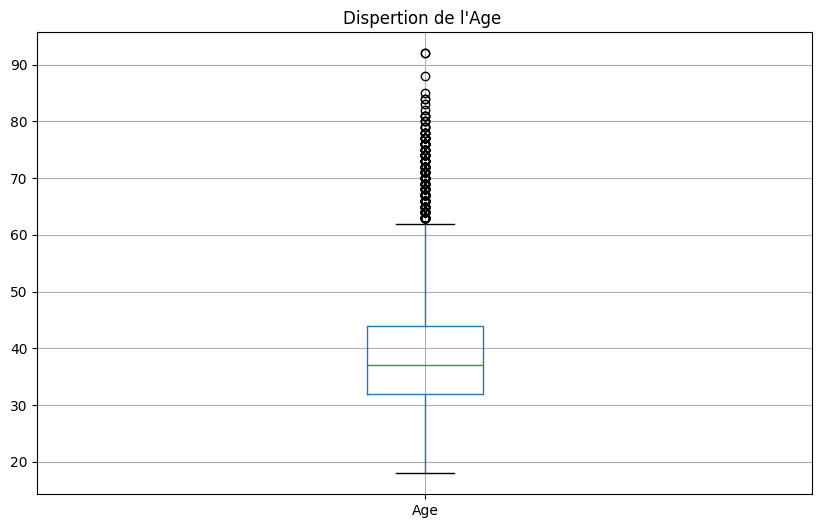

coef asymétrie = 1.0113202630234552


In [118]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl 
#  Analyse de l'age avec boxplot 
plt.figure(figsize=(10,6))
df.boxplot("Age")
plt.title("Dispertion de l'Age ")
plt.show()
print(f"coef asymétrie = {df["Age"].skew()}")

=> Analyse des valeurs abérrantes de la variable CreditScore

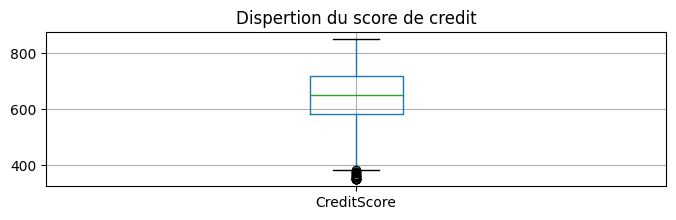

coef asymétrie = -0.07160660820092675


In [119]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl 
plt.figure(figsize=(8,2))
df.boxplot("CreditScore")
plt.title("Dispertion du score de credit")
plt.show()
print(f"coef asymétrie = {df["CreditScore"].skew()}")


##### => Analyse de la variable Abérrantes NumOfProducts

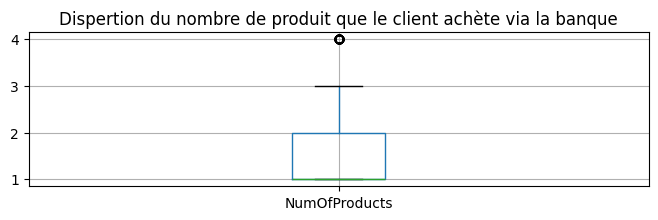

coef asymétrie = 0.7455678882823168


In [120]:
plt.figure(figsize=(8,2))
df.boxplot("NumOfProducts")
plt.title("Dispertion du nombre de produit que le client achète via la banque")
plt.show()
print(f"coef asymétrie = {df["NumOfProducts"].skew()}")


## 02- Analyse Univariée 

#### 02.1- Statistiques descriptives

In [121]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


#### - Analyse des coéfficients d'asymétrie

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
num_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'EstimatedSalary',
    'Satisfaction Score', 'Point Earned'
]


existing_cols = [col for col in num_cols if col in df.columns]


for col in existing_cols:
    skew_val = df[col].skew()
    print(f"{col:20} → asymétrie = {skew_val:.4f}")

CreditScore          → asymétrie = -0.0716
Age                  → asymétrie = 1.0113
Tenure               → asymétrie = 0.0110
Balance              → asymétrie = -0.1411
NumOfProducts        → asymétrie = 0.7456
EstimatedSalary      → asymétrie = 0.0021
Satisfaction Score   → asymétrie = -0.0089
Point Earned         → asymétrie = 0.0083


#### 02.2- Analyse Graphique

##### 1- Analyse graphique de la distribution des variables quantitatives

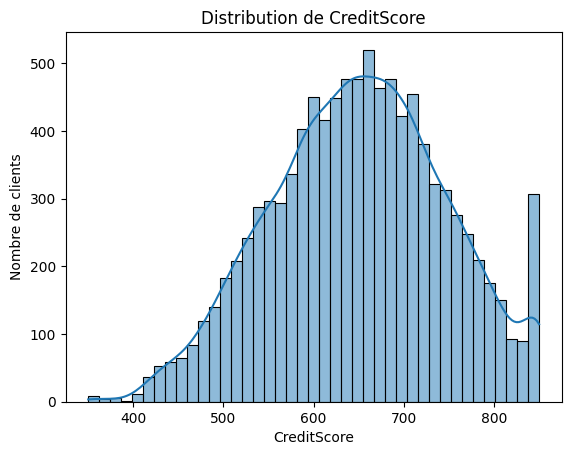

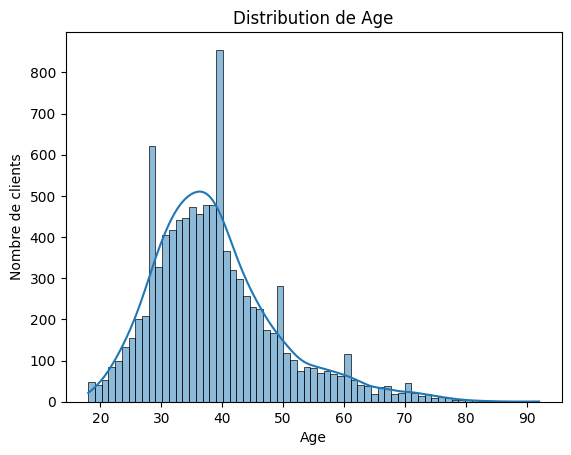

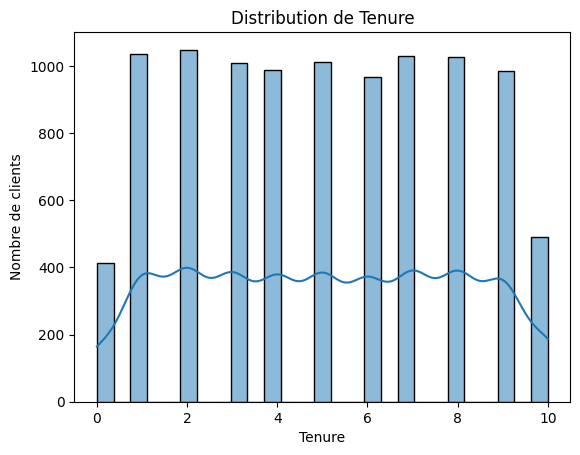

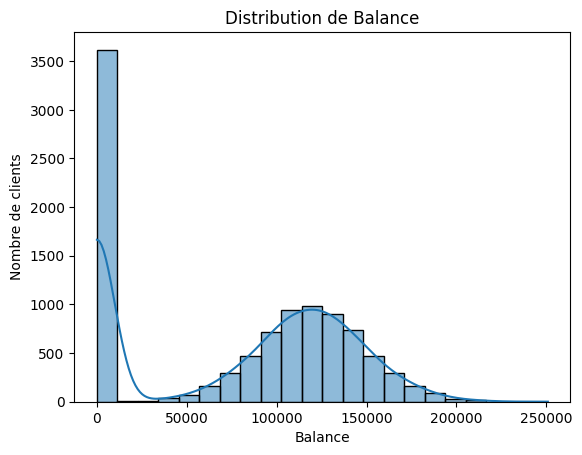

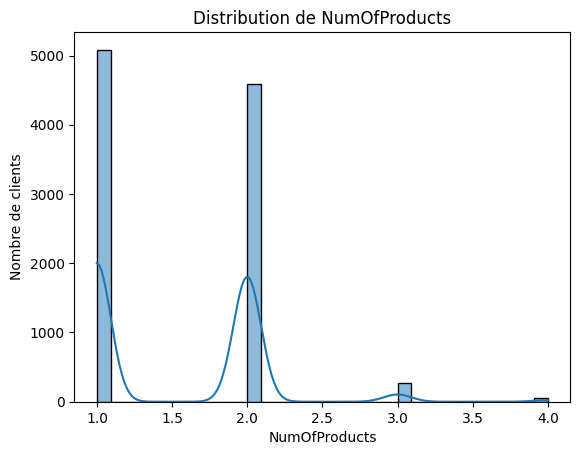

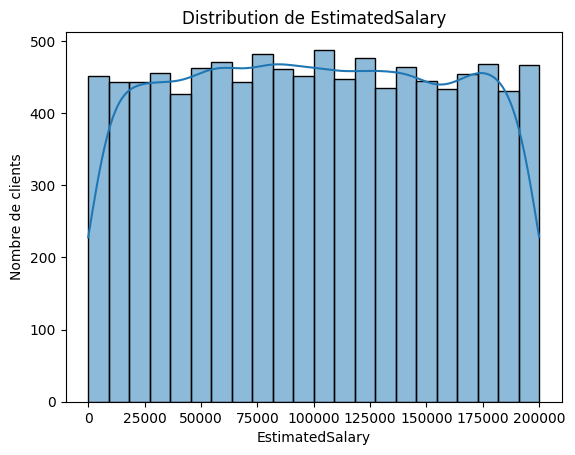

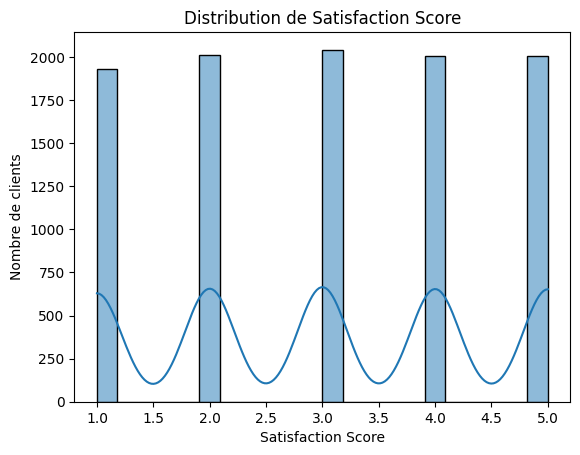

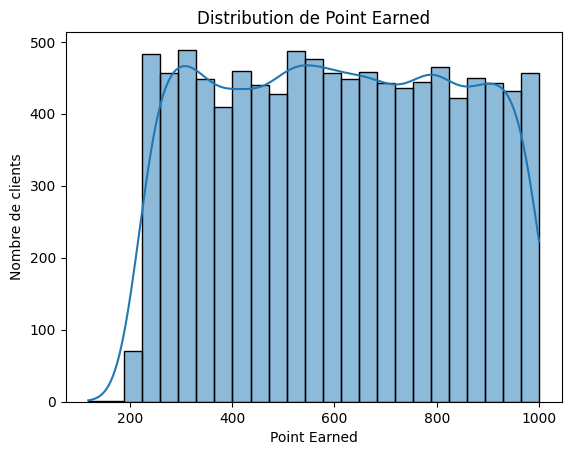

In [123]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl
num_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'EstimatedSalary',
    'Satisfaction Score', 'Point Earned'
]

for col in num_cols:
    plt.figure()
    sn.histplot(df[col], kde=True)
    plt.ylabel("Nombre de clients")
    plt.title(f"Distribution de {col}")
    plt.show()

##### 2- Analyse graphique de la distribution des variables qualitatives

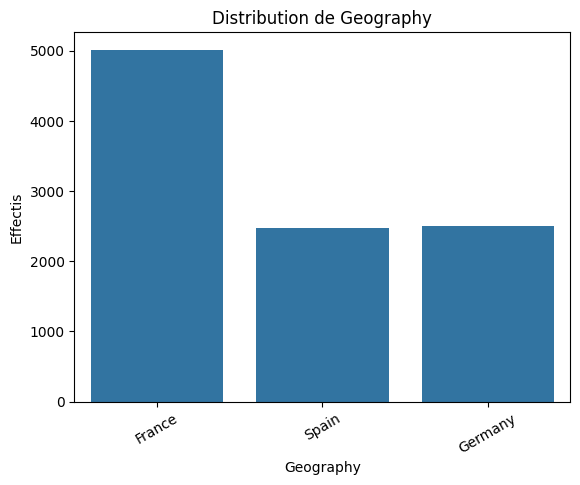

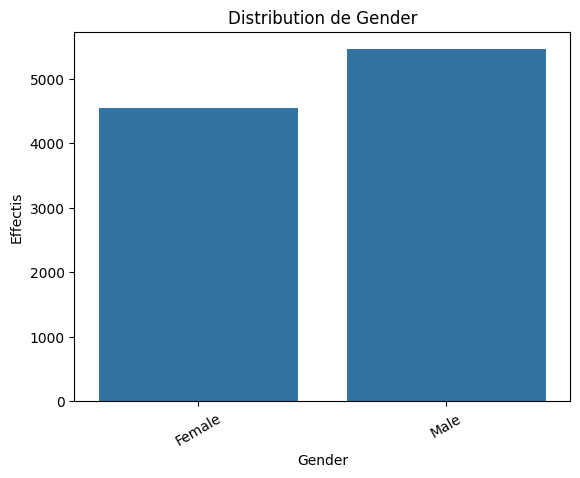

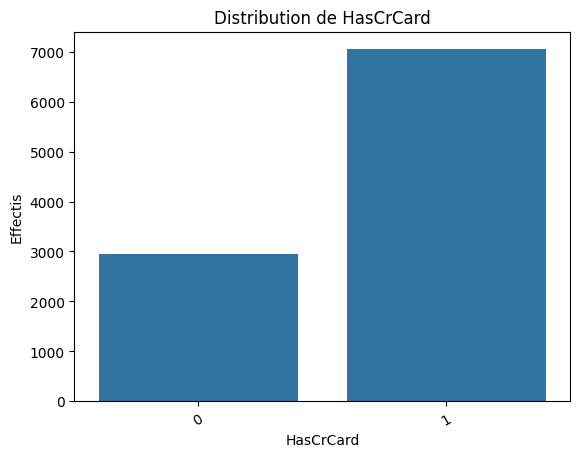

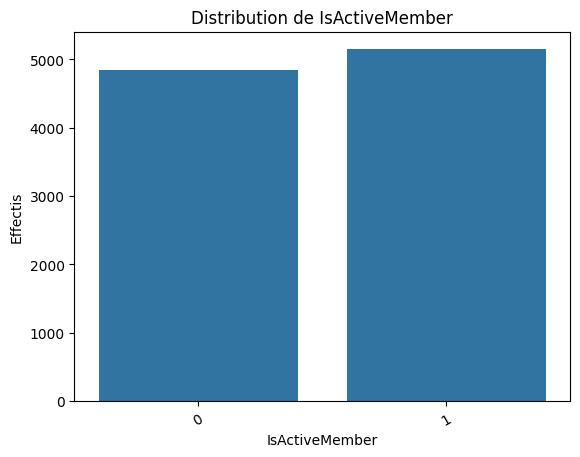

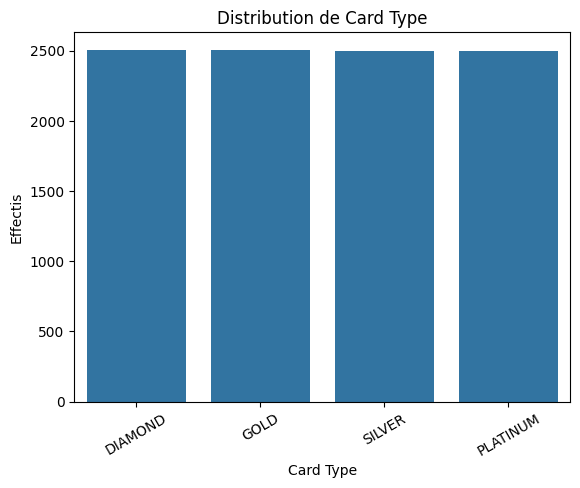

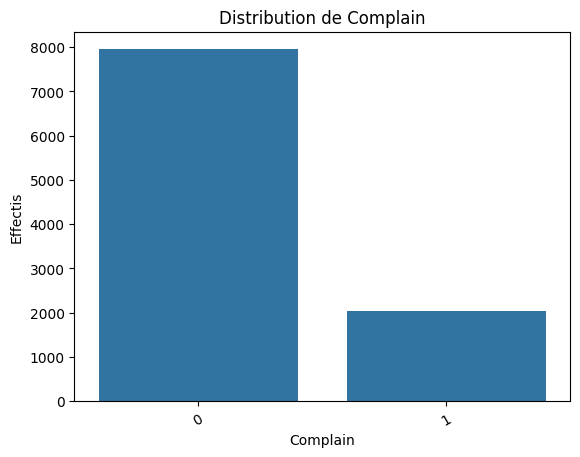

In [124]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl
cat_cols = [
    'Geography', 'Gender', 'HasCrCard',
    'IsActiveMember', 'Card Type', 'Complain'
]

for col in cat_cols:
    plt.figure()
    sn.countplot( x=col, data=df)
    plt.title(f"Distribution de {col}")
    plt.ylabel("Effectis")
    plt.xticks(rotation=30)
    plt.show()

##### => Analyse du Churn des Clients

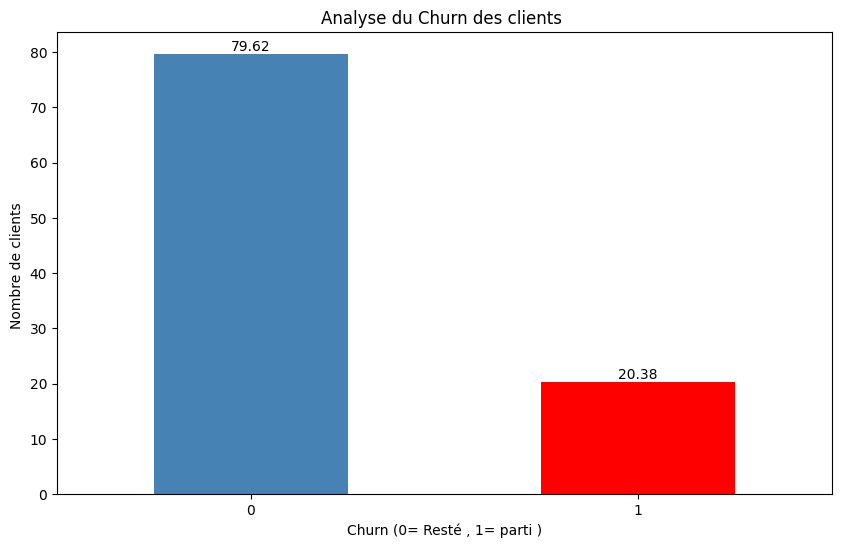

In [125]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl 
Partis = df["Exited"].value_counts(normalize=True)*100
ax01 = Partis.plot(kind="bar",figsize= (10, 6), color=["steelblue", "red"])
for container in ax01.containers:
    ax01.bar_label(container)
plt.title("Analyse du Churn des clients ")
plt.xlabel("Churn (0= Resté , 1= parti )")
plt.ylabel("Nombre de clients ")
plt.xticks(rotation=0)
plt.show()

## 03- Analyse Bivariée

#### 03.1 Analyse de l'association des variables quantitatives avec la variable cible Exited 

##### 1- Analyse des ecarts des variables dans les différents groupes 

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("./../Data/Data_brut/Customer-Churn-Records.csv")

df = df.drop(columns=[
    "RowNumber",  
    "CustomerId",  
    "Surname",     
     
])


NUM_VARS  = ["CreditScore", "Age", "Tenure", "Balance",
             "EstimatedSalary", "Satisfaction Score", "Point Earned", "NumOfProducts" ]

CHURN_GLOBAL = df["Exited"].mean()  

print(f"Population : {len(df):,} clients")
print(f"Taux_partis global : {CHURN_GLOBAL*100:.2f}%\n")
print("\n\n" + "=" * 70)
print("ANALYSE DES ECARTS DANS LES GROUPES VARIABLES QUANTITATIVES vs EXITED")
print("=" * 70)
g0 = df[df["Exited"] == 0]   
g1 = df[df["Exited"] == 1]   

print(f"\n{'Variable':<20} {'Moy. restés':>12} {'Moy. partis':>15} "
      f"{'Écart':>10} {'Écart %':>9}"
      )

print("─" * 70)

resultats_4 = []
for var in NUM_VARS:
    m0   = g0[var].mean()
    m1   = g1[var].mean()
    diff = m1 - m0
    diff_pct = diff / m0 * 100 if m0 != 0 else np.nan
    
    print(f"{var:<20} {m0:>12.2f} {m1:>15.2f} {diff:>+10.2f} "
          f"{diff_pct:>+8.1f}%  "
          )

    resultats_4.append({
        "variable": var, "mean_0": m0, "mean_1": m1,
        "diff": diff, "diff_pct": diff_pct,
       
    })







Population : 10,000 clients
Taux_partis global : 20.38%



ANALYSE DES ECARTS DANS LES GROUPES VARIABLES QUANTITATIVES vs EXITED

Variable              Moy. restés     Moy. partis      Écart   Écart %
──────────────────────────────────────────────────────────────────────
CreditScore                651.84          645.41      -6.42     -1.0%  
Age                         37.41           44.84      +7.43    +19.9%  
Tenure                       5.03            4.93      -0.10     -1.9%  
Balance                  72742.75        91109.48  +18366.73    +25.2%  
EstimatedSalary          99726.85       101509.91   +1783.06     +1.8%  
Satisfaction Score           3.02            3.00      -0.02     -0.7%  
Point Earned               607.04          604.45      -2.60     -0.4%  
NumOfProducts                1.54            1.48      -0.07     -4.5%  


##### 2- Analyse de l'association des variables quantitative à la variable cible (Exited)

In [127]:

import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency, fisher_exact

df = pd.read_csv("./../Data/Data_brut/Customer-Churn-Records.csv")

target = "Exited"

explicatives = ["Age", "CreditScore", "Balance", "NumOfProducts",
                "EstimatedSalary", "HasCrCard", "Tenure",
                "IsActiveMember", "Satisfaction Score",   "Complain", "Point Earned" ]

results = []

for var in explicatives:
    x = df[var]
    y = df[target]

    unique_val = x.unique()
  
    if set(unique_val).issubset({0, 1}):
    
        tab = pd.crosstab(x, y)
        chi2, p_chi2, dof, exp = chi2_contingency(tab)
        n = tab.sum().sum()
        phi = np.sqrt(chi2 / n)
        _, p_fisher = fisher_exact(tab)
        
        results.append({
            "variable": var,
            "type": "binaire",
            "mesure": "phi",
            "valeur": phi,
            "p_value": p_fisher
        })
    
    elif len(unique_val) <= 10:
        
        tab = pd.crosstab(x, y) 
        chi2, p_chi2, dof, exp = chi2_contingency(tab) 
        n = tab.sum().sum()
        cramer = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
        
        results.append({
            "variable": var,
            "type": f"discrète ({len(unique_val)} valeurs)",
            "mesure": "V de Cramer",
            "valeur": cramer,
            "p_value": p_chi2
        })
    else:
       
        corr, p_val = pointbiserialr(x, y)  
        
        results.append({
            "variable": var,
            "type": "continue",
            "mesure": "corrélation bisériale",
            "valeur": corr,
            "p_value": p_val
        })


print("\n" + "="*60)
print("Association avec la variable cible 'Exited'")
print("="*60 + "\n")

for r in results:
    print(f" {r['variable']} [{r['type']}]")
    print(f"   → {r['mesure']} = {r['valeur']:.4f}")
    print(f"   → p-value = {r['p_value']:.6f}")
    
    if r['p_value'] < 0.05:
        print("  ✅  Association statistiquement significative")
    else:
        print("   ❌ Non significative")
    print()


print("\n" + "="*60)
print("Tableau récapitulatif")
print("="*60)
summary = pd.DataFrame(results) 
print(summary.to_string(index=False))
  



Association avec la variable cible 'Exited'

 Age [continue]
   → corrélation bisériale = 0.2853
   → p-value = 0.000000
  ✅  Association statistiquement significative

 CreditScore [continue]
   → corrélation bisériale = -0.0268
   → p-value = 0.007422
  ✅  Association statistiquement significative

 Balance [continue]
   → corrélation bisériale = 0.1186
   → p-value = 0.000000
  ✅  Association statistiquement significative

 NumOfProducts [discrète (4 valeurs)]
   → V de Cramer = 0.3875
   → p-value = 0.000000
  ✅  Association statistiquement significative

 EstimatedSalary [continue]
   → corrélation bisériale = 0.0125
   → p-value = 0.211715
   ❌ Non significative

 HasCrCard [binaire]
   → phi = 0.0067
   → p-value = 0.496018
   ❌ Non significative

 Tenure [continue]
   → corrélation bisériale = -0.0137
   → p-value = 0.172104
   ❌ Non significative

 IsActiveMember [binaire]
   → phi = 0.1561
   → p-value = 0.000000
  ✅  Association statistiquement significative

 Satisfaction 

##### 3- Analyse graphique des variables quantitatives prises vs Exited

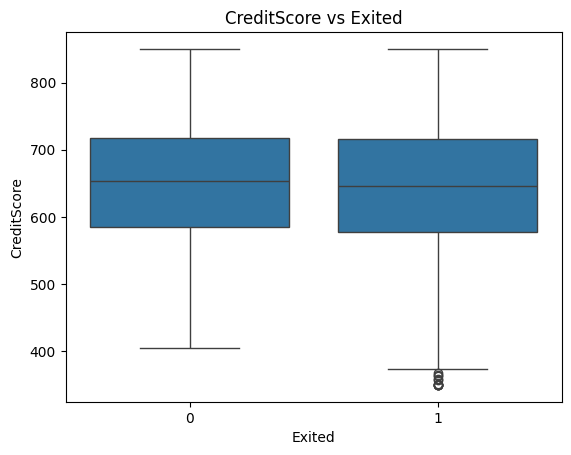

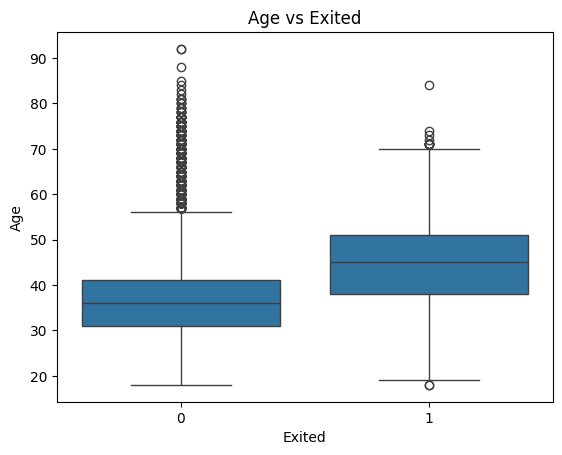

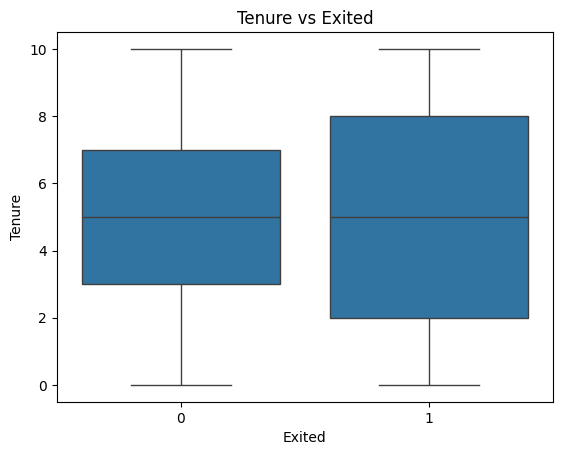

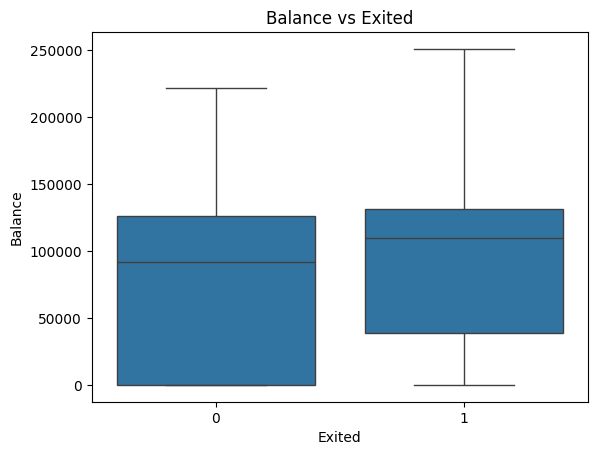

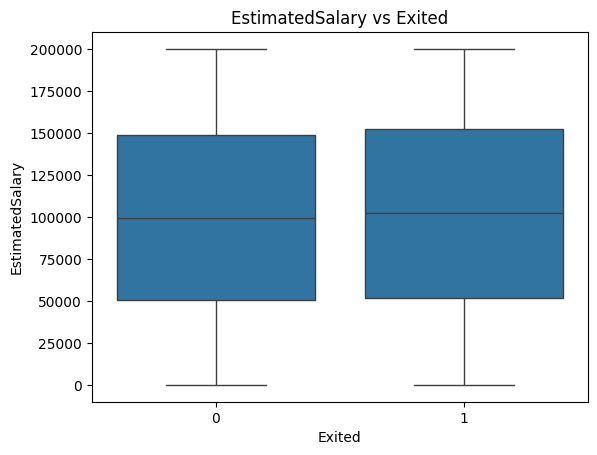

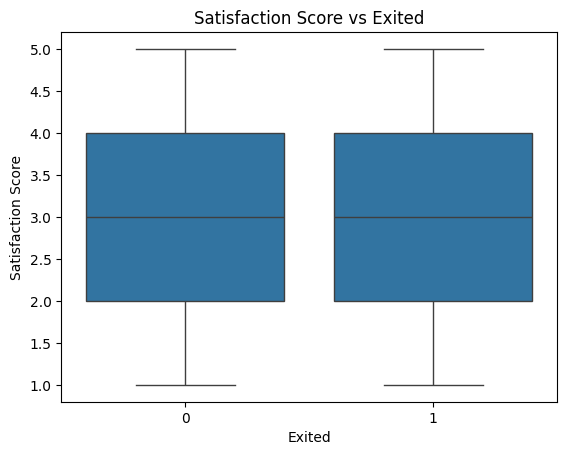

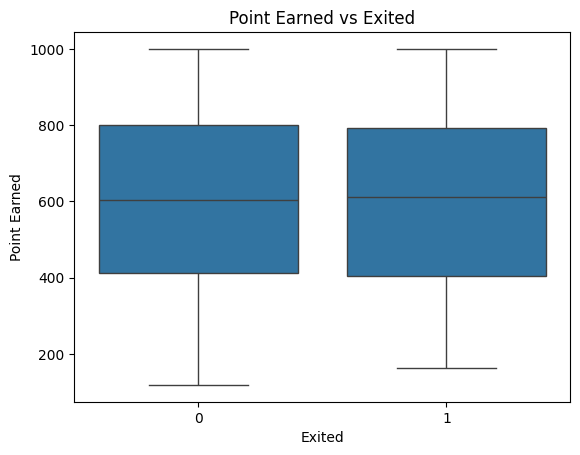

In [128]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl
num_cols = ["CreditScore", "Age", "Tenure", "Balance",
                "EstimatedSalary", "Satisfaction Score", "Point Earned"]
for col in num_cols:
    plt.figure()
    sn.boxplot(x='Exited', y=col, data=df )
    plt.title(f"{col} vs Exited")
    plt.show()

#### 03.2 Analyse de l'association des variables quantitatives avec la variable cible Exited 

##### 1- Statistique descriptive :  Calcul du Odds Ratio et du V de Cramèr pour anlyser les relations entre  variables qualitative et ainsi que le groupe de client (parti/resté)

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

BLEU   = "#2196F3"   
ROUGE  = "#F44336"  
ORANGE = "#FF9800"  
VERT   = "#4CAF50"


df = pd.read_csv("../Data/Data_brut/Customer-Churn-Records.csv")
df["actif_finance"] = (df["Balance"] > 0).astype(int)


QUAL_VARS = ["Geography", "Gender", "Card Type"]


CHURN_GLOBAL = df["Exited"].mean() 

print(f"Nombre de clients : {len(df):,} clients")
print(f"Taux_clients_partis global : {CHURN_GLOBAL*100:.2f}%\n")
print("=" * 65)
print(" ANALYSE DES VARIABLES QUALITATIVES vs EXITED")
print("=" * 65)
print("""
Méthodes utilisées:
  - Tableau de contingence (effectifs absolus)
  - Taux de Départ par modalité (proportion réelle dans la population)
  - Ecart au taux global (en points de pourcentage)
  - V de Cramér (force / l'intensité de l'association)
  - Odds Ratio (risque relatif de départ entre modalités)
""")


def cramers_v(var, df):
    """
    V de Cramér : mesure la force de l'association entre une variable
    qualitative et Exited. V ∈ [0,1].
    Interprétation : <0.1 faible | 0.1-0.3 modéré | ≥0.3 fort.
    C'est une mesure DESCRIPTIVE — utilisable sur une population entière.
    """
    ct = pd.crosstab(df[var], df["Exited"])
    n  = ct.values.sum()
    chi2 = 0
    expected = np.outer(ct.sum(axis=1), ct.sum(axis=0)) / n
    chi2 = ((ct.values - expected) ** 2 / expected).sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))


def odds_ratio(var, df):
    """
    Calcule l'Odds Ratio de chaque modalité vs toutes les autres.
    OR > 1 : cette modalité churne plus que le reste de la population.
    OR < 1 : cette modalité churne moins que le reste de la population.
    OR = 1 : aucun effet différentiel.
    """
    ct  = pd.crosstab(df[var], df["Exited"])
    ors = {}
    for mod in ct.index:
        a = ct.loc[mod, 1]              
        b = ct.loc[mod, 0]              
        c = ct[1].sum() - a             
        d = ct[0].sum() - b             
        if 0 in [a, b, c, d]:
            a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
        ors[mod] = (a * d) / (b * c)
    return ors


def interprete_v(v):
    if v >= 0.3:  return "Fort      🔴"
    if v >= 0.1:  return "Modéré    🟡"
    return              "Faible    🟢"


print(f"\n{'Variable':<20} {'V Cramér':>9} {'Force':>15}  {'Taux_Parti par modalité'}")
print("─" * 80)

for var in QUAL_VARS:
    v   = cramers_v(var, df)
    ors = odds_ratio(var, df)
    taux = df.groupby(var)["Exited"].mean()
    detail = "  |  ".join(
        f"{str(m)}: {t*100:.1f}% (OR={ors[m]:.2f})"
        for m, t in taux.items()
    )
    print(f"{var:<20} {v:>9.4f} {interprete_v(v):>15}  {detail}")#va


print("\n\n── Analyse des départ par variable ──────────────────────────────")
for var in QUAL_VARS:
    ct   = pd.crosstab(df[var], df["Exited"])
    taux = df.groupby(var)["Exited"].mean()
    ors  = odds_ratio(var, df)
    v    = cramers_v(var, df)

    resume = pd.DataFrame({
        "N total":       ct.sum(axis=1),
        "N Restés":      ct[0],
        "N Partis":     ct[1],
        "Taux_partis":    taux.map("{:.1%}".format),
        "Écart / global": (taux - CHURN_GLOBAL).map(
            lambda x: f"{x*100:+.1f} pp"),
        "Odds Ratio":    pd.Series(ors).map("{:.2f}".format),
    })

    print(f"\n{'─'*55}")
    print(f"  {var}  |  V de Cramér = {v:.4f}  [{interprete_v(v).strip()}]")
    print(f"{'─'*55}")
    print(resume.to_string())




Nombre de clients : 10,000 clients
Taux_clients_partis global : 20.38%

 ANALYSE DES VARIABLES QUALITATIVES vs EXITED

Méthodes utilisées:
  - Tableau de contingence (effectifs absolus)
  - Taux de Départ par modalité (proportion réelle dans la population)
  - Ecart au taux global (en points de pourcentage)
  - V de Cramér (force / l'intensité de l'association)
  - Odds Ratio (risque relatif de départ entre modalités)


Variable              V Cramér           Force  Taux_Parti par modalité
────────────────────────────────────────────────────────────────────────────────
Geography               0.1734     Modéré    🟡  France: 16.2% (OR=0.59)  |  Germany: 32.4% (OR=2.46)  |  Spain: 16.7% (OR=0.73)
Gender                  0.1063     Modéré    🟡  Female: 25.1% (OR=1.70)  |  Male: 16.5% (OR=0.59)
Card Type               0.0225     Faible    🟢  DIAMOND: 21.8% (OR=1.12)  |  GOLD: 19.3% (OR=0.91)  |  PLATINUM: 20.4% (OR=1.00)  |  SILVER: 20.1% (OR=0.98)


── Analyse des départ par variable ───

##### 2- Analyse graphique des variables qualitatives vs Exited prises 

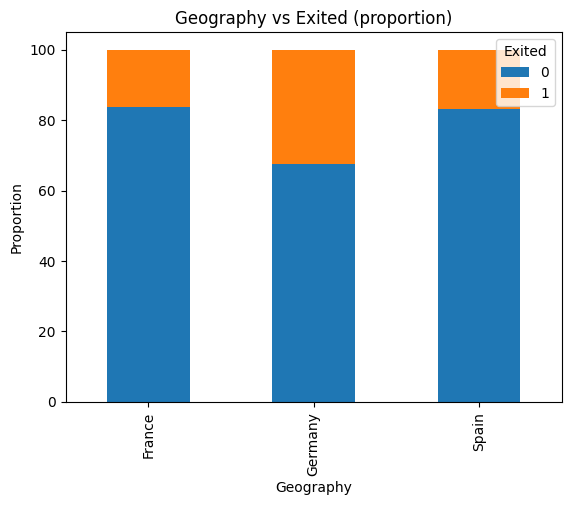

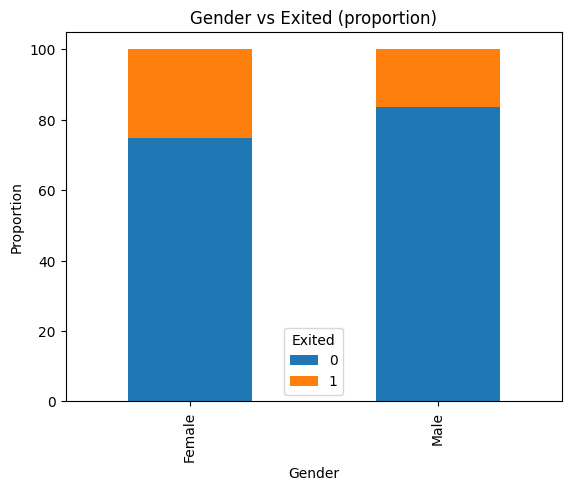

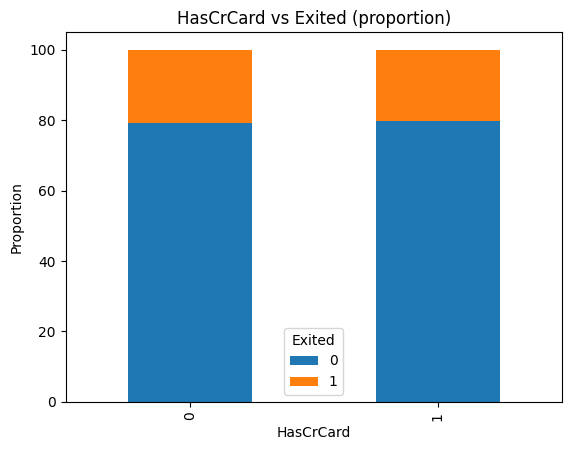

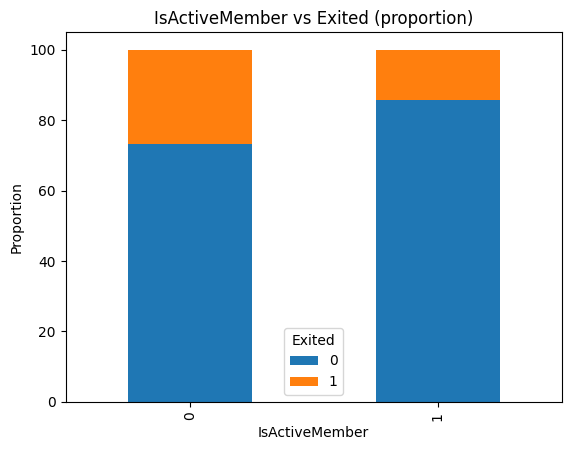

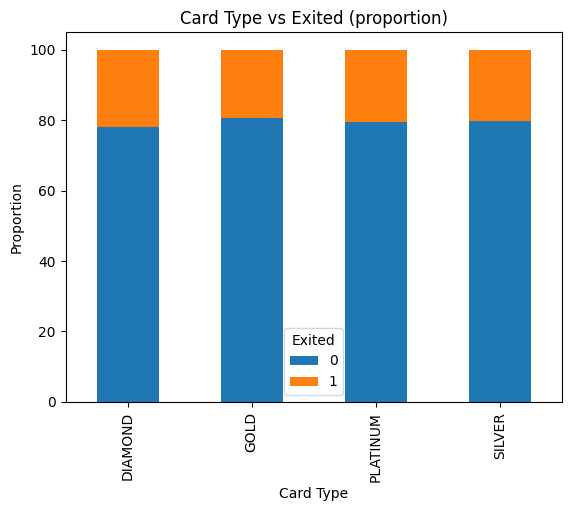

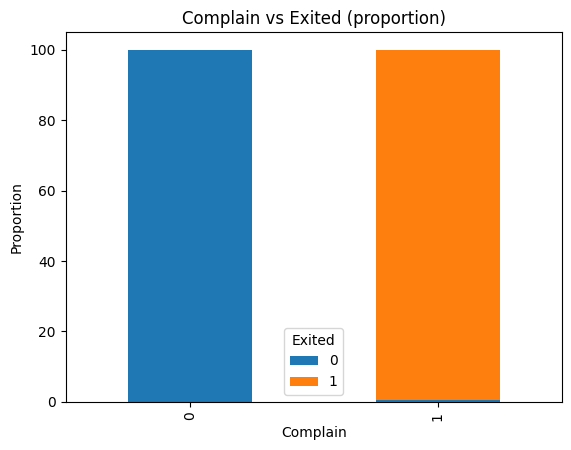

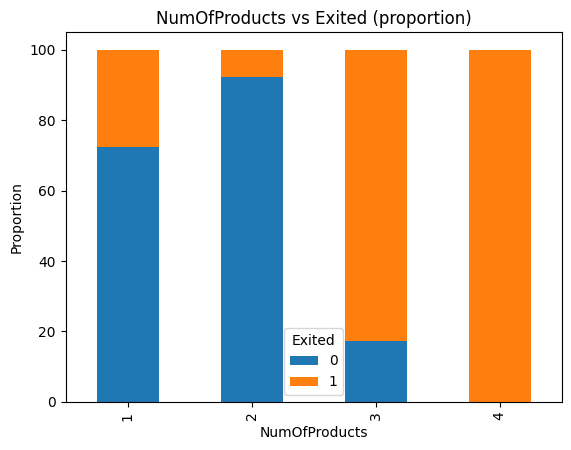

In [130]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import sklearn  as skl
cat_cols = [
    'Geography', 'Gender', 'HasCrCard',
    'IsActiveMember', 'Card Type', 'Complain', 'NumOfProducts'
]

for col in cat_cols:
    ct = pd.crosstab(df[col], df['Exited'], normalize='index')*100
    ct.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Exited (proportion)")
    plt.ylabel("Proportion")
    plt.show()

In [131]:
df = df.drop(columns=[
     
    "RowNumber", "CustomerId", "Surname"
])

In [132]:
df = df.drop(columns=[
     
    "actif_finance"
])

In [133]:
df= df.drop(columns=[
     
    "Complain"
])

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Card Type           10000 non-null  object 
 13  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [135]:
nombre = (df['Balance']==0).sum()
print(nombre)

3617
